In [11]:
import openmc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import os
from scipy.interpolate import make_interp_spline

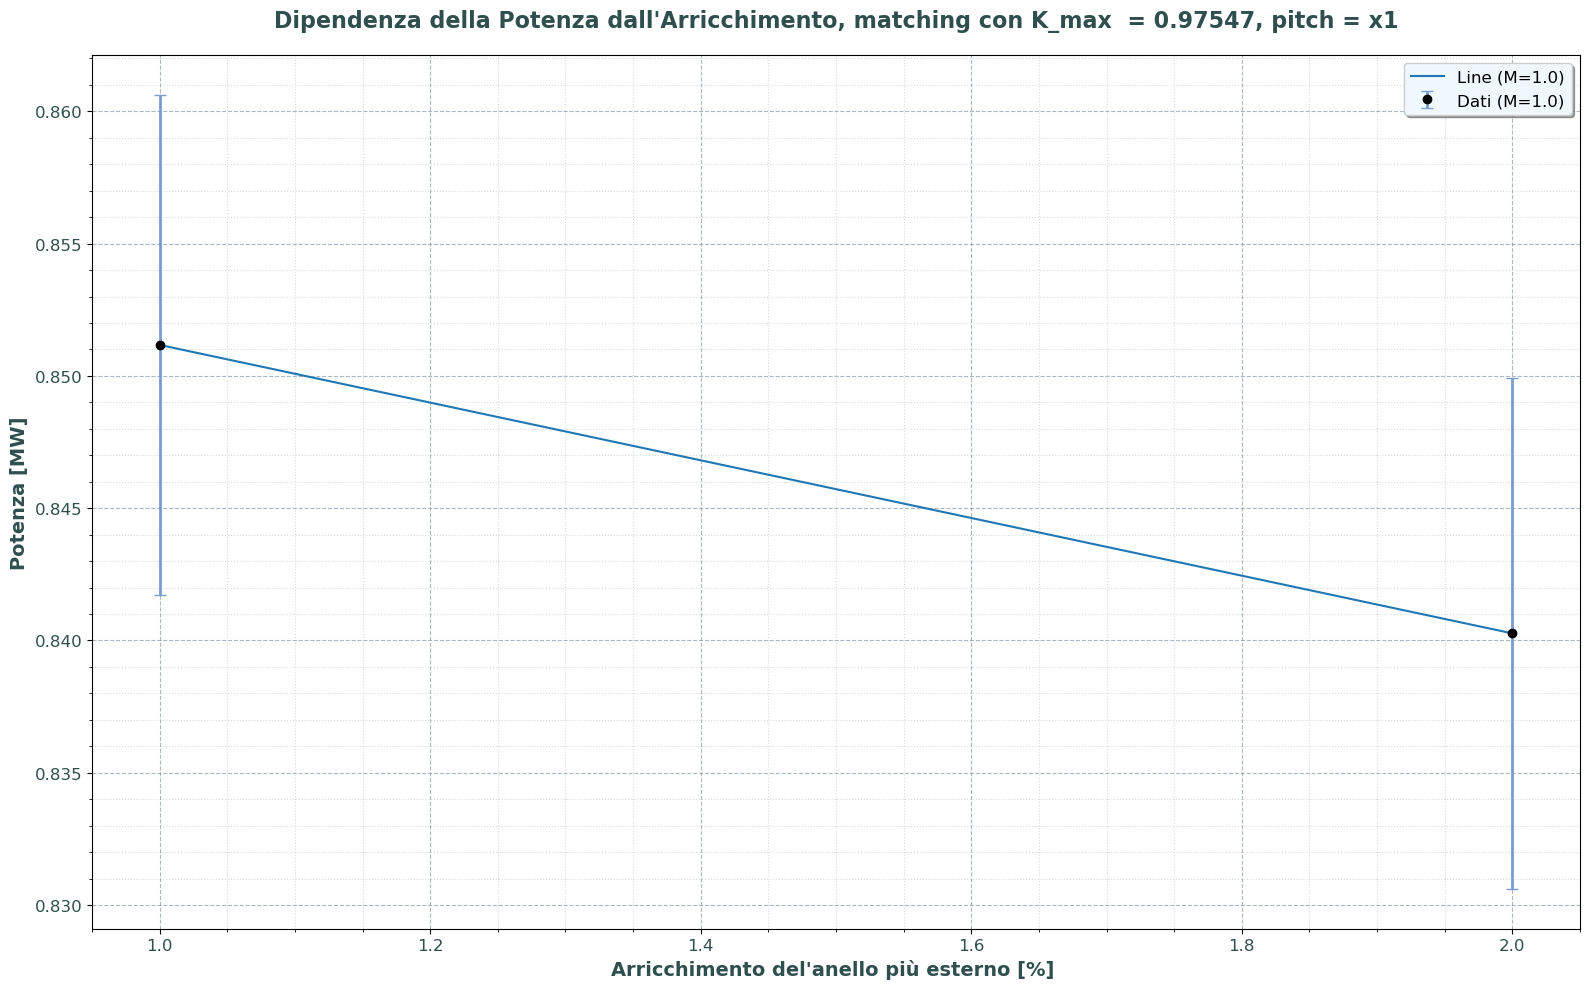

In [12]:
E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5, estrae media e deviazione standard delle fissioni, calcola potenza e incertezza."""
    file_list = glob.glob("statepoint_arr_ext_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    pattern = re.compile(r"statepoint_arr_ext_(\d+)_pitch_([\d\.]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        moltiplicatore = float(match.group(2))
        arricchimento = float(match.group(1)) 
        
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0] # Estrazione errore statistico
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza e Incertezza [MW]
        potenza_MW = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        errore_MW = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        dati.append({
            'Arricchimento': arricchimento,
            'Moltiplicatore': moltiplicatore,
            'Potenza_MW': potenza_MW,
            'Errore_MW': errore_MW
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Genera plot a dispersione con barre di errore e interpolazione spline cubica."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    moltiplicatori = df['Moltiplicatore'].unique()
    
    for m in moltiplicatori:
        df_m = df[df['Moltiplicatore'] == m].sort_values(by='Arricchimento')
        
        x = df_m['Arricchimento'].values
        y = df_m['Potenza_MW'].values
        y_err = df_m['Errore_MW'].values
        
        # Plot dei punti centrali con barre di errore (styling rigoroso)
        ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                    elinewidth=2, capsize=4, zorder=5, label=f'Dati (M={m})')
        
        # Interpolazione morbida
        if len(x) >= 3:
            x_smooth = np.linspace(x.min(), x.max(), 300)
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            ax.plot(x_smooth, y_smooth, zorder=4, label=f'Spline (M={m})')
        else:
            ax.plot(x, y, zorder=4, label=f'Line (M={m})')
            
    # Formattazione
    ax.set_title('Dipendenza della Potenza dall\'Arricchimento, matching con K_max  = 0.97547, pitch = x1', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento del\'anello più esterno [%] ', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, 
              fontsize=12, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.savefig('scatter_potenza_errore.png', dpi=300)
    plt.show()

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)